In [ ]:
import ee
import geemap

In [ ]:
# 1. Initialize Google Earth Engine
try:
    ee.Initialize(project="desertification-risk")
except Exception as e:
    ee.Authenticate()
    ee.Initialize(project="desertification-risk")

### Geometry of Sindh is defined

In [ ]:
# 2. Define the Region of Interest: Sindh Province
pakistan_districts = ee.FeatureCollection("FAO/GAUL/2015/level1")
sindh = pakistan_districts.filter(ee.Filter.eq('ADM1_NAME', 'Sindh'))
sindh_geom = sindh.geometry()

### World Cover categories are remaped

In [ ]:
# 3. Load ESA WorldCover 10m Dataset for Stratification
worldcover = ee.Image("ESA/WorldCover/v100/2020").select('Map')

In [ ]:
# 4. Remap ESA Classes to your 4 Custom Strata
# ESA Classes: 40=Cropland, 60=Bare/Desert, 20=Shrubland, 30=Grassland, 90=Wetlands, 95=Mangroves
# Custom Strata: 1=Agriculture, 2=Arid/Desert, 3=Shrub/Grass, 4=Coastal/Mangrove
from_classes = [40, 60, 20, 30, 90, 95]
to_classes   = [ 1,  2,  3,  3,  4,  4]

In [ ]:
# Create a new image where pixels equal 1, 2, 3, or 4
strata_image = worldcover.remap(from_classes, to_classes, defaultValue=0).rename('strata').clip(sindh_geom)

In [ ]:
# Mask out '0' so we only sample inside our target ecological zones
strata_image = strata_image.updateMask(strata_image.gt(0))

The below allocation uses stratified disproportionate sampling to prevent rare, high-value ecosystems (wetlands/mangroves) from being statistically erased by the dominant land classes (desert/cropland) while maintaining sufficient sample density to capture spectral variance.

In [ ]:
# 5. Perform the Stratified Sampling
print("Generating 1000 Stratified Patches... (This may take a few seconds)")
stratified_points = strata_image.stratifiedSample(
    numPoints=0, # Overridden by classPoints below
    classBand='strata',
    region=sindh_geom,
    scale=10,  # Native 10m Sentinel resolution
    seed=42,
    classValues=[1, 2, 3, 4],
    classPoints=[300, 300, 200, 200], # Your exact requested distribution
    geometries=True # Crucial: tells GEE to return actual map coordinates!
)

Generating 1000 Stratified Patches... (This may take a few seconds)


In [ ]:
# stratified_points

In [ ]:
# Split each strata in half using a sequence number property
def add_index_within_strata(strata_id, total):
    strata_points = stratified_points.filter(ee.Filter.eq('strata', strata_id)).toList(total)
    half = total // 2

    original = ee.FeatureCollection(strata_points.slice(0, half))
    new      = ee.FeatureCollection(strata_points.slice(half, total))
    return original, new

orig_s1, new_s1 = add_index_within_strata(1, 300)  # 150 each
orig_s2, new_s2 = add_index_within_strata(2, 300)  # 150 each
orig_s3, new_s3 = add_index_within_strata(3, 200)  # 100 each
orig_s4, new_s4 = add_index_within_strata(4, 200)  # 100 each

original_500 = orig_s1.merge(orig_s2).merge(orig_s3).merge(orig_s4)
new_500      = new_s1.merge(new_s2).merge(new_s3).merge(new_s4)

In [ ]:
original_500

In [ ]:
# # Verify strata distribution
# for s in [1, 2, 3, 4]:
#     n_orig = original_500.filter(ee.Filter.eq('strata', s)).size().getInfo()
#     n_new  = new_500.filter(ee.Filter.eq('strata', s)).size().getInfo()
#     print(f'Strata {s} — Original: {n_orig}, New: {n_new}')

Strata 1 — Original: 150, New: 150
Strata 2 — Original: 150, New: 150
Strata 3 — Original: 100, New: 100
Strata 4 — Original: 100, New: 100


In [ ]:
# 3. Generate 10-meter Resolution Patches
PATCH_RESOLUTION = 10 # 10 meters per pixel (Sentinel Native Resolution)
PATCH_SIZE_PIXELS = 64 # We want a 64x64 tensor for the CNN

# Calculate the buffer radius needed to make a 640m x 640m box
# 64 pixels * 10m = 640m total width. Radius from center is 320m.
BUFFER_RADIUS = (PATCH_SIZE_PIXELS / 2) * PATCH_RESOLUTION

In [ ]:
def point_to_box(feature):
    box = feature.geometry().buffer(BUFFER_RADIUS).bounds()
    # We keep the 'strata' label attached to the box so we know what type it is later!
    return ee.Feature(box, {'strata': feature.get('strata')})

In [ ]:
original_patches = original_500.map(point_to_box)
new_patches = new_500.map(point_to_box)


print(f"Successfully generated {original_patches.size().getInfo()} original and {new_patches.size().getInfo()} new stratified patches!")

Successfully generated 500 original and 500 new stratified patches!


In [ ]:
def check_overlap():
    # Spatial join — find new patches that intersect any original patch
    filter_intersects = ee.Filter.intersects(
        leftField='.geo', rightField='.geo', maxError=1
    )
    overlapping = ee.Join.simple().apply(
        primary   = new_patches,
        secondary = original_patches,
        condition = filter_intersects
    )
    n_overlap = overlapping.size().getInfo()
    print(f"Overlapping patches: {n_overlap} (should be 0 or very small)")
    return n_overlap

overlap_count = check_overlap()

Overlapping patches: 16 (should be 0 or very small)


In [ ]:
# 1. Create an interactive map centered roughly on Sindh, Pakistan
# Coordinates [26.0, 68.5] and zoom level 6 give a good overview of the province
Map = geemap.Map(center=[26.0, 68.5], zoom=6)

# 2. Add the Sindh Province boundary for context
# We use a red outline with a transparent fill so we can see the satellite imagery below
sindh_style = {'color': 'red', 'fillColor': '00000000', 'width': 2}
Map.addLayer(sindh.style(color='red', fillColor='00000000', width=2), {}, "Sindh Boundary")

In [ ]:
# We will color-code the boxes so you can verify the stratification worked
# 1=Ag (Green), 2=Desert (Yellow), 3=Shrub (Orange), 4=Coastal (Blue)
def colorize_patches(feature):
    strata = ee.Number(feature.get('strata'))
    color = ee.Algorithms.If(strata.eq(1), '00FF00', # Green
            ee.Algorithms.If(strata.eq(2), 'FFFF00', # Yellow
            ee.Algorithms.If(strata.eq(3), 'FFA500', # Orange
                                           '0000FF'))) # Blue (4)
    return feature.set('style', {'color': color, 'fillColor': ee.String(color).cat('44'), 'width': 2})

styled_patches = sampled_patches.map(colorize_patches)
Map.addLayer(styled_patches.style(styleProperty='style'), {}, "Stratified 64x64 Patches")

Map

Map(center=[26.0, 68.5], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(…

# Data Collection

## Preparing Data

In [ ]:
import os
import ee
import geemap
from datetime import datetime
from dateutil.relativedelta import relativedelta


def mask_s2_clouds(image):
    """Masks clouds, shadows, and cirrus in Sentinel-2 using the SCL band."""
    scl = image.select('SCL')

    # SCL Classes to remove:
    # 3 = Cloud shadows
    # 8 = Cloud (medium probability)
    # 9 = Cloud (high probability)
    # 10 = Cirrus
    mask = scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10))

    # Apply the mask and divide by 10000 to convert reflectance to 0-1 scale
    return image.updateMask(mask).divide(10000)

In [ ]:
# ==========================================
# 2. CORE 10-DATASET EXTRACTION FUNCTION
# ==========================================
def get_comprehensive_yearly_timeseries(patch_geom, start_year):
    """
    Loops through 12 months natively on Google's servers.
    Calculates 33 Features + 5 MEDALUS targets.
    Returns a single image with 456 bands (12 months x 38 channels).
    """

    start_date = ee.Date.fromYMD(start_year, 1, 1)

    def extract_month(m):
        m_start = start_date.advance(m, 'month')
        m_end = m_start.advance(1, 'month')
        current_year = m_start.get('year')

        # --- 1. SENTINEL-1 (Radar) ---
        dummy_s1 = ee.Image.constant([0, 0]).rename(['VV', 'VH']).updateMask(0)
        s1_col = ee.ImageCollection('COPERNICUS/S1_GRD') \
            .filterBounds(patch_geom).filterDate(m_start, m_end) \
            .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
            .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')) \
            .filter(ee.Filter.eq('instrumentMode', 'IW'))
        s1 = s1_col.merge(ee.ImageCollection([dummy_s1]))


        # Backscatter Coefficient (sigma-nought) & Ratio
        s1_vv = s1.select('VV').median().unmask(-30).rename('S1_VV')
        s1_vh = s1.select('VH').median().unmask(-30).rename('S1_VH')
        s1_ratio = s1_vh.subtract(s1_vv).rename('S1_Ratio') # VH_dB - VV_dB

        # --- 2. SENTINEL-2 (Optical & High-Res Indices) ---
        dummy_s2 = ee.Image.constant([0, 0, 0, 0]).rename(['B2', 'B4', 'B8', 'B11']).updateMask(0)
        s2_col = ee.ImageCollection('COPERNICUS/S2_SR') \
            .filterBounds(patch_geom).filterDate(m_start, m_end) \
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 60)).map(mask_s2_clouds)
        s2 = s2_col.merge(ee.ImageCollection([dummy_s2]))

        s2_bands = s2.select(['B2', 'B4', 'B8', 'B11']).median().unmask(0).rename(['Blue', 'Red', 'NIR', 'SWIR'])

        # Computing Indices (Adding 1e-6 to denominators to prevent Division by Zero)
        ndvi = s2_bands.normalizedDifference(['NIR', 'Red']).rename('NDVI')
        ndwi = s2_bands.normalizedDifference(['NIR', 'SWIR']).rename('NDWI')
        msi = s2_bands.select('SWIR').divide(s2_bands.select('NIR').add(1e-6)).rename('MSI')
        nddi = ndvi.subtract(ndwi).divide(ndvi.add(ndwi).add(1e-6)).rename('NDDI')

        # SAVI: L = 0.5 is standard for mixed vegetation
        savi = s2_bands.expression(
            '((NIR - RED) / (NIR + RED + 0.5)) * 1.5',
            {'NIR': s2_bands.select('NIR'), 'RED': s2_bands.select('Red')}
        ).rename('SAVI')

        # EVI: (G=2.5, C1=6, C2=7.5, L=1)
        evi = s2_bands.expression(
            '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))',
            {'NIR': s2_bands.select('NIR'), 'RED': s2_bands.select('Red'), 'BLUE': s2_bands.select('Blue')}
        ).rename('EVI')

        # --- 3. MODIS (Thermal & Structural) ---
        # LST: Land Surface Temperature (Scale 0.02, subtract 273.15 for Celsius)
        dummy_lst = ee.Image.constant(0).rename(['LST_Day_1km']).updateMask(0)
        lst_col = ee.ImageCollection("MODIS/006/MOD11A2").filterBounds(patch_geom).filterDate(m_start, m_end)
        lst = lst_col.merge(ee.ImageCollection([dummy_lst]))
        lst_celsius = lst.select('LST_Day_1km').mean().multiply(0.02).subtract(273.15).unmask(0).rename('MODIS_LST')

        # ET: Evapotranspiration
        dummy_et = ee.Image.constant(0).rename(['ET']).updateMask(0)
        et_col = ee.ImageCollection("MODIS/006/MOD16A2").filterBounds(patch_geom).filterDate(m_start, m_end)
        et = et_col.merge(ee.ImageCollection([dummy_et]))
        et_modis = et.select('ET').sum().unmask(0).rename('MODIS_ET')

        # LAI: Leaf Area Index (Scale factor 0.1)
        dummy_lai = ee.Image.constant(0).rename(['Lai']).updateMask(0)
        lai_col = ee.ImageCollection("MODIS/061/MCD15A3H").filterBounds(patch_geom).filterDate(m_start, m_end)
        lai = lai_col.merge(ee.ImageCollection([dummy_lai]))
        lai_modis = lai.select('Lai').mean().multiply(0.1).unmask(0).rename('MODIS_LAI')

        # --- 4. CHIRPS (Rainfall) ---
        dummy_chirps = ee.Image.constant(0).rename(['precipitation']).updateMask(0)
        chirps_col = ee.ImageCollection("UCSB-CHG/CHIRPS/DAILY").filterBounds(patch_geom).filterDate(m_start, m_end)
        chirps = chirps_col.merge(ee.ImageCollection([dummy_chirps]))
        rain = chirps.select('precipitation').sum().unmask(0).rename('CHIRPS_Rainfall')

        # --- 5. TerraClimate (Climate Models) ---
        dummy_tc = ee.Image.constant([0,0,0,0,0,0]).rename(['pr', 'pet', 'tmmx', 'tmmn', 'vpd', 'pdsi']).updateMask(0)
        tc_col = ee.ImageCollection("IDAHO_EPSCOR/TERRACLIMATE").filterBounds(patch_geom).filterDate(m_start, m_end)
        tc = tc_col.merge(ee.ImageCollection([dummy_tc]))


        tc_pr = tc.select('pr').sum().unmask(0).rename('TC_Pr')
        tc_pet = tc.select('pet').sum().multiply(0.1).unmask(0).rename('TC_PET') # Scale 0.1
        tc_tmax = tc.select('tmmx').mean().multiply(0.1).unmask(0).rename('TC_Tmax') # Scale 0.1
        tc_tmin = tc.select('tmmn').mean().multiply(0.1).unmask(0).rename('TC_Tmin') # Scale 0.1
        tc_vpd = tc.select('vpd').mean().multiply(0.01).unmask(0).rename('TC_VPD') # Scale 0.01
        tc_pdsi = tc.select('pdsi').mean().multiply(0.01).unmask(0).rename('TC_PDSI') # Scale 0.01

        # --- 6. Soil Properties (Static) ---
        soc = ee.Image("OpenLandMap/SOL/SOL_ORGANIC-CARBON_USDA-6A1C_M/v02").select('b0').unmask(0).rename('Soil_SOC')
        texture = ee.Image("OpenLandMap/SOL/SOL_TEXTURE-CLASS_USDA-TT_M/v02").select('b0').unmask(0).rename('Soil_Texture')
        bulk_density = ee.Image("projects/soilgrids-isric/bdod_mean").select('bdod_0-5cm_mean').unmask(0).rename('Soil_BulkDensity')

        # --- 7. Topography (Static) ---
        srtm = ee.Image("USGS/SRTMGL1_003").clip(patch_geom)
        elevation = srtm.rename("Topo_Elevation")
        slope = ee.Terrain.slope(srtm).rename("Topo_Slope")
        aspect = ee.Terrain.aspect(srtm).rename("Topo_Aspect")
        hillshade = ee.Terrain.products(srtm).select('hillshade').rename("Topo_Hillshade") # Swapped TRI for Hillshade

        # --- 8. Night Lights (VIIRS - Monthly proxy for human activity) ---
        dummy_viirs = ee.Image.constant(0).rename(['avg_rad']).updateMask(0)
        viirs_col = ee.ImageCollection("NOAA/VIIRS/DNB/MONTHLY_V1/VCMCFG").filterBounds(patch_geom).filterDate(m_start, m_end)
        viirs = viirs_col.merge(ee.ImageCollection([dummy_viirs]))
        night_lights = viirs.select('avg_rad').median().unmask(0).rename('VIIRS_NightLights')


        # 9. Population (Dynamic 5-Year Epochs capped at 2020)
        # ==========================================
        # GPWv4 data caps at 2020. We use 2015 for older data, and 2020 for everything newer.
        # Dynamic Population based on year
        pop_year = ee.Algorithms.If(ee.Number(current_year).lt(2020), 2015, 2020)
        pop_15 = ee.ImageCollection("CIESIN/GPWv411/GPW_Population_Density").filterDate('2015-01-01', '2015-12-31').first()
        pop_20 = ee.ImageCollection("CIESIN/GPWv411/GPW_Population_Density").filterDate('2020-01-01', '2020-12-31').first()
        pop = ee.Image(ee.Algorithms.If(ee.Number(current_year).lt(2020), pop_15, pop_20))
        pop_dens = ee.Image(ee.Algorithms.If(pop, pop.select('population_density'), ee.Image.constant(0))).unmask(0).rename('Pop_Density')



        # 10. Land Cover Class (Google Dynamic World - 10m Monthly!)
        # ==========================================
        # Dynamic World Classes:
        # 0=water, 1=trees, 2=grass, 3=flooded_veg, 4=crops, 5=shrub, 6=built, 7=bare, 8=snow
        dummy_dw = ee.Image.constant(0).rename(['label']).updateMask(0)
        dw_col = ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1").filterBounds(patch_geom).filterDate(m_start, m_end)
        dw = dw_col.merge(ee.ImageCollection([dummy_dw]))

        # We use .mode() to get the most common land cover class for that specific month
        # We unmask with 7 (bare land) as a safe default for arid regions if data is missing
        lc = dw.select('label').mode().unmask(7).rename('Land_Cover')


        # 1. CLIMATE QUALITY INDEX (CQI)
        # Inverse: Rain, PDSI (wetter is better) | Direct: LST, VPD (hotter/drier is worse)
        f_rain = ee.Image(1).subtract(rain.unitScale(0, 300).clamp(0.01, 1))
        f_pdsi = ee.Image(1).subtract(tc_pdsi.unitScale(-4, 4).clamp(0.01, 1)) # PDSI: -4 (dry) to +4 (wet)
        f_temp = lst_celsius.unitScale(10, 50).clamp(0.01, 1)
        f_vpd = tc_vpd.unitScale(0, 5).clamp(0.01, 1) # Vapor Pressure Deficit

        cqi = f_rain.multiply(f_pdsi).multiply(f_temp).multiply(f_vpd).pow(0.25).rename('CQI')


        # 2. VEGETATION QUALITY INDEX (VQI)
        # Inverse: NDVI, SAVI, EVI (more veg is better) | Direct: NDDI (more drought stress is worse)
        f_ndvi = ee.Image(1).subtract(ndvi.unitScale(-0.2, 0.8).clamp(0.01, 1))
        f_savi = ee.Image(1).subtract(savi.unitScale(-0.2, 0.8).clamp(0.01, 1))
        f_evi = ee.Image(1).subtract(evi.unitScale(-0.2, 0.8).clamp(0.01, 1))
        f_nddi = nddi.unitScale(-1, 1).clamp(0.01, 1)

        vqi = f_ndvi.multiply(f_savi).multiply(f_evi).multiply(f_nddi).pow(0.25).rename('VQI')


        # 3. SOIL QUALITY INDEX (SQI)
        # Inverse: SOC, Water Capacity, NDWI (more moisture/carbon is better) | Direct: Slope (steeper = more erosion)
        f_soc = ee.Image(1).subtract(soc.unitScale(0, 50).clamp(0.01, 1))
        f_bulk = bulk_density.unitScale(100, 180).clamp(0.01, 1)
        f_ndwi = ee.Image(1).subtract(ndwi.unitScale(-0.5, 0.5).clamp(0.01, 1))
        f_slope = slope.unitScale(0, 30).clamp(0.01, 1) # Degrees

        sqi = f_soc.multiply(f_bulk).multiply(f_ndwi).multiply(f_slope).pow(0.25).rename('SQI')


        # 4. LAND QUALITY/MANAGEMENT INDEX (LQI)
        # Map Dynamic World classes to sensitivity scores [0 to 1]
        # 0=water(0), 1=trees(0.1), 2=grass(0.5), 3=flooded_veg(0.2), 4=crops(0.4),
        # 5=shrub(0.6), 6=built(0.9), 7=bare(1.0), 8=snow(0)
        from_classes = [0, 1, 2, 3, 4, 5, 6, 7, 8]
        to_scores = [0.01, 0.1, 0.5, 0.2, 0.4, 0.6, 0.9, 1.0, 0.01]
        f_lc_sens = lc.remap(from_classes, to_scores, 0.5).rename('LC_Sens')

        # Direct: Pop Density, Night Lights (more human activity = more stress)
        f_pop = pop_dens.unitScale(0, 500).clamp(0.01, 1)
        f_lights = night_lights.unitScale(0, 50).clamp(0.01, 1)

        lqi = f_lc_sens.multiply(f_pop).multiply(f_lights).pow(1/3).rename('LQI')



        # 5. FINAL DESERTIFICATION SENSITIVITY INDEX (DSI)
        # Geometric Mean: DSI = (CQI * VQI * SQI * LQI)^(1/4)
        dsi = cqi.multiply(vqi).multiply(sqi).multiply(lqi).pow(0.25).rename('DSI')


        # ==========================================
        # 3. COMBINE INTO MASTER TENSOR
        # ==========================================
        monthly_stack = ee.Image.cat([
            s1_vv, s1_vh, s1_ratio,                                # 3 bands
            s2_bands, ndvi, ndwi, msi, nddi, savi, evi,            # 10 bands
            lst_celsius, et_modis, lai_modis,                      # 3 bands
            rain,                                                  # 1 band
            tc_pr, tc_pet, tc_tmax, tc_tmin, tc_vpd, tc_pdsi,      # 6 bands
            soc, texture, bulk_density,                                 # 3 bands
            elevation, slope, aspect, hillshade,                   # 4 bands
            night_lights, pop_dens, lc,
            cqi, vqi, sqi, lqi, dsi
        ]).clip(patch_geom)                                        # TOTAL: 33 Channels

        # Float32 is critical for PyTorch / Kaggle memory limits
        return monthly_stack.toFloat()

    # Create sequence of 12 months (0 to 11)
    month_sequence = ee.List.sequence(0, 11)
    # Map function across all 12 months on Google's servers
    yearly_collection = ee.ImageCollection.fromImages(month_sequence.map(extract_month))
    # toBands() flattens 12 images * 38 channels = 456 channel image!
    return yearly_collection.toBands().clip(patch_geom)



## Downloading Data (GEE -> Drive)

In [ ]:
# # 4. AUTOMATED GOOGLE DRIVE EXPORT LOOP
# # ==========================================
# # Note: Ensure `new_patches` exists from Snippet 2.
# patch_list = new_patches.getInfo()['features']

# # This is the literal name of the folder that will appear in your Google Drive
# drive_folder_base = "Sindh_CNN_Dataset"

# # Define time range
# years_to_process = range(2024, 2027)              ## For training 2016-2023, For testing 2024-2026


# print(f"Initializing Export for {len(patch_list)} patches. Tensors will have 38 channels at 10m resolution.")

# for target_year in years_to_process:

#     year_folder = f"{drive_folder_base}_{target_year}"

#     print(f"\n--- SUBMITTING YEAR: {target_year} to folder: {year_folder} ---")

#     for i, patch in enumerate(patch_list):
#         # Retrieve strata ID so we keep our dataset organized by ecological zone
#         strata_id = patch['properties']['strata']
#         patch_geom = ee.Geometry.Polygon(patch['geometry']['coordinates'])

#         # Task Name indicates it is a stacked yearly file
#         task_name = f"Patch_{i:03d}_Strata_{strata_id}_{target_year}_Stacked"

#         # Calls the 456-band extraction function
#         yearly_tensor = get_comprehensive_yearly_timeseries(patch_geom, target_year)



#         print(f"\nSubmitting tasks for Patch {i} (Strata {strata_id})...")

#         try:
#             task = ee.batch.Export.image.toDrive(
#                 image=yearly_tensor,
#                 description=task_name,
#                 folder=year_folder,
#                 region=patch_geom,
#                 scale=10,
#                 maxPixels=1e10,
#                 fileFormat='GeoTIFF'
#             )
#             task.start()
#             print(f"  [+] Submitted task: {task_name}")
#         except Exception as e:
#             print(f"  [-] Failed to submit Patch {i}: {e}")



# print("\nAll tasks successfully submitted to Google Earth Engine!")
# print("Check https://code.earthengine.google.com/tasks to monitor their progress.")

In [ ]:
# import ee

# print("Fetching task list from Google Earth Engine...")
# tasks = ee.batch.Task.list()

# canceled_count = 0

# for task in tasks:
#     # We only want to cancel tasks that are actively stuck or waiting.
#     # We ignore 'COMPLETED' or 'FAILED' tasks because they are already done.
#     if task.state in ['READY', 'RUNNING']:
#         task.cancel()
#         canceled_count += 1

# print(f"\nSUCCESS: Sent cancellation command for {canceled_count} tasks!")
# print("Refresh your GEE Tasks page in a few seconds; they will turn grey (Cancelled).")

Fetching task list from Google Earth Engine...

SUCCESS: Sent cancellation command for 333 tasks!
Refresh your GEE Tasks page in a few seconds; they will turn grey (Cancelled).


## Plotting Data

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# 1. DEFINE THE FILE PATH
# Replace this with the actual path to a downloaded .tif file in your Drive
file_path = "/content/drive/MyDrive/Sindh_CNN_Dataset_2020/Patch_206_Strata_2_2020_Stacked.tif"

In [ ]:
# 2. LOAD THE TENSOR
print(f"Opening file: {file_path.split('/')[-1]}")
with rasterio.open(file_path) as src:
    # Read the data. Rasterio loads it as (Bands, Height, Width)
    raw_tensor = src.read()

print(f"Raw Tensor Shape: {raw_tensor.shape} (Expected: 456, H, W)")

Opening file: Patch_206_Strata_2_2020_Stacked.tif
Raw Tensor Shape: (456, 65, 71) (Expected: 456, H, W)


In [ ]:
# 3. RESHAPE INTO TIME-SERIES (Months, Channels, Height, Width)
num_months = 12
num_channels = 38
height = raw_tensor.shape[1]
width = raw_tensor.shape[2]

timeseries_tensor = raw_tensor.reshape((num_months, num_channels, height, width))
print(f"Time-Series Shape: {timeseries_tensor.shape} (12 Months, 38 Channels, {height}, {width})")

Time-Series Shape: (12, 38, 65, 71) (12 Months, 38 Channels, 65, 71)


In [ ]:
month_idx = 9

Lqi_october = timeseries_tensor[month_idx, 36, :, :]
dsi_october = timeseries_tensor[month_idx, 37, :, :]

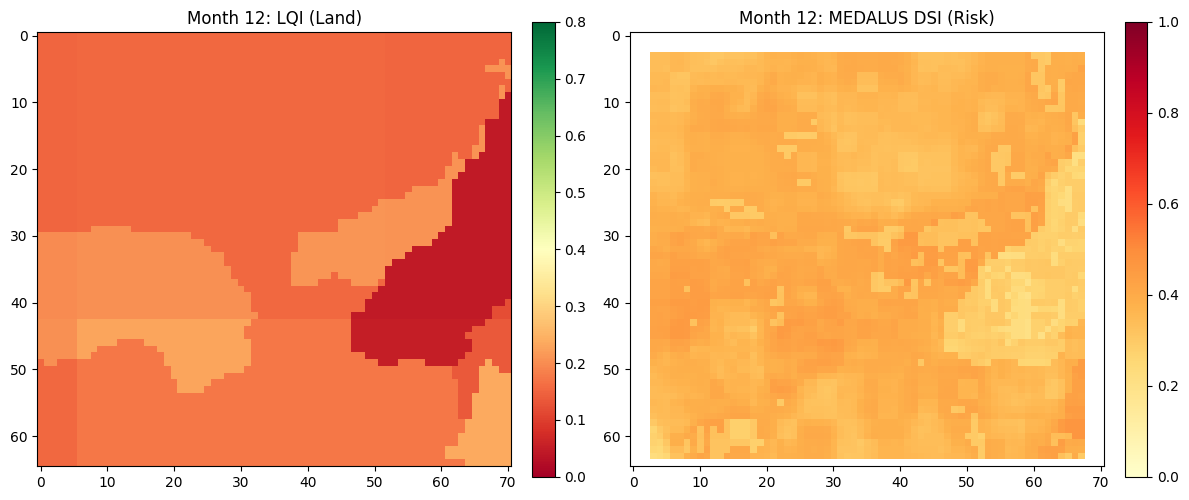

In [ ]:
# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: NDVI (Vegetation Health)
im1 = axes[0].imshow(Lqi_october, cmap='RdYlGn', vmin=0, vmax=0.8)
axes[0].set_title("Month 12: LQI (Land)")
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

# Plot 2: DSI (Desertification Risk)
# DSI is geometric mean of risk [0 to 1], so higher = more desertified
im2 = axes[1].imshow(dsi_october, cmap='YlOrRd', vmin=0, vmax=1)
axes[1].set_title("Month 12: MEDALUS DSI (Risk)")
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Loading the Data

In [ ]:
import os
import re
import glob
import torch
import rasterio
import numpy as np
import torchvision.transforms.functional as TF
from sklearn.model_selection import train_test_split

In [ ]:
# ==========================================
# 1. SETUP DIRECTORIES
# ==========================================
# Where your GEE folders (Sindh_CNN_Dataset_2016, etc.) are located
raw_data_base_dir = "/content/drive/MyDrive/"

# Where to save the final PyTorch tensors
output_base_dir = "/content/drive/MyDrive/Processed_Sindh_Dataset"
# os.makedirs(os.path.join(output_base_dir, "train"), exist_ok=True)
# os.makedirs(os.path.join(output_base_dir, "val"), exist_ok=True)
os.makedirs(os.path.join(output_base_dir, "test"), exist_ok=True)

# Timeframes
# train_val_years = range(2016, 2024) # 2016 to 2023 (8 years = 96 months)
test_years = range(2024, 2027)      # 2024 to 2026 (2 years + 2 months = 26 months)

In [ ]:
# ==========================================
# 2. IDENTIFY PATCHES & STRATIFIED SPLIT
# ==========================================
print("Scanning directories for patches...")
# Look in the 2022 folder (or any year) to get the master list of all 500 patches
sample_folder = os.path.join(raw_data_base_dir, "Sindh_CNN_Dataset_2022")
all_files = glob.glob(os.path.join(sample_folder, "*.tif"))

patch_info = []
for f in all_files:
    filename = os.path.basename(f)
    # Extract Patch ID and Strata using Regex (e.g., from "Patch_000_Strata_1_2022_Stacked.tif")
    match = re.search(r"Patch_(\d+)_Strata_(\d+)", filename)
    if match:
        patch_info.append({
            "patch_id": match.group(1),
            "strata": int(match.group(2))
        })

# Extract just the IDs and Strata for the split
patch_ids = [p['patch_id'] for p in patch_info]
strata_labels = [p['strata'] for p in patch_info]

# Stratified Split: 80% Train (400), 20% Val (100)
train_ids, val_ids = train_test_split(
    patch_ids,
    test_size=0.20,
    stratify=strata_labels,
    random_state=42 # Fixed seed for reproducibility
)

print(f"Total Patches Found: {len(patch_ids)}")
print(f"Training Patches: {len(train_ids)} | Validation Patches: {len(val_ids)}")

Scanning directories for patches...
Total Patches Found: 500
Training Patches: 400 | Validation Patches: 100


In [ ]:
# ==========================================
# 3. PROCESSING FUNCTION
# ==========================================
def process_year_sequence(patch_id, strata_id, years, expected_months):
    """Loads a sequence of years, crops, and concatenates along the time dimension."""
    yearly_tensors = []

    for year in years:
        keep_months = 2 if year == 2026 else 12

        folder_name = f"Sindh_CNN_Dataset_{year}"
        file_name = f"Patch_{patch_id}_Strata_{strata_id}_{year}_Stacked.tif"
        file_path = os.path.join(raw_data_base_dir, folder_name, file_name)

        if os.path.exists(file_path):
            with rasterio.open(file_path) as src:
                img_data = src.read()

            # Clean NaNs
            img_data = np.nan_to_num(img_data, nan=0.0,  posinf=0.0, neginf=0.0)
            tensor_data = torch.tensor(img_data, dtype=torch.float32)

            # Crop to exactly 64x64
            tensor_data = TF.center_crop(tensor_data, output_size=(64, 64))

            # Reshape to (12, 38, 64, 64)
            tensor_data = tensor_data.view(12, 38, 64, 64)

            tensor_data = tensor_data[:keep_months]

        else:
            print(f"  [WARNING] Missing {file_name}. Filling with zeros.")
            # Fallback if a GEE task failed: inject 12 months of zeros
            tensor_data = torch.zeros((keep_months, 38, 64, 64), dtype=torch.float32)

        yearly_tensors.append(tensor_data)

    # Concatenate all years along the Time dimension (dim=0)
    # Result: (96, 38, 64, 64) or (26, 38, 64, 64)
    final_sequence = torch.cat(yearly_tensors, dim=0)
    assert final_sequence.shape[0] == expected_months, "Time dimension mismatch!"

    return final_sequence

## Storing Processed Tensors

In [ ]:
# ==========================================
# 4. EXECUTE PIPELINE
# ==========================================
print("\nStarting Tensor Generation...")

for p in patch_info:
    p_id = p['patch_id']
    s_id = p['strata']
    print(f"Processing Patch {p_id} (Strata {s_id})...")

    # # --- A. TRAIN / VAL SEQUENCE (2016 - 2023) ---
    # seq_96 = process_year_sequence(p_id, s_id, train_val_years, expected_months=96)

    # # Route to correct folder based on the stratified split
    # if p_id in train_ids:
    #     save_path = os.path.join(output_base_dir, "train", f"Patch_{p_id}_Strata_{s_id}.pt")
    # else:
    #     save_path = os.path.join(output_base_dir, "val", f"Patch_{p_id}_Strata_{s_id}.pt")

    # torch.save(seq_96, save_path)

    # --- B. HOLDOUT TEST SEQUENCE (2024 - 2026) ---
    # Every patch gets a 26-month test sequence saved
    seq_26 = process_year_sequence(p_id, s_id, test_years, expected_months=26)
    test_save_path = os.path.join(output_base_dir, "test", f"Patch_{p_id}_Strata_{s_id}.pt")
    torch.save(seq_26, test_save_path)

print("\nDataset Pre-Processing Complete! All files are perfectly shaped and saved.")


Starting Tensor Generation...
Processing Patch 000 (Strata 1)...
Processing Patch 002 (Strata 1)...
Processing Patch 001 (Strata 1)...
Processing Patch 003 (Strata 1)...
Processing Patch 005 (Strata 1)...
Processing Patch 006 (Strata 1)...
Processing Patch 008 (Strata 1)...
Processing Patch 007 (Strata 1)...
Processing Patch 009 (Strata 1)...
Processing Patch 010 (Strata 1)...
Processing Patch 011 (Strata 1)...
Processing Patch 012 (Strata 1)...
Processing Patch 013 (Strata 1)...
Processing Patch 014 (Strata 1)...
Processing Patch 015 (Strata 1)...
Processing Patch 017 (Strata 1)...
Processing Patch 016 (Strata 1)...
Processing Patch 019 (Strata 1)...
Processing Patch 018 (Strata 1)...
Processing Patch 021 (Strata 1)...
Processing Patch 020 (Strata 1)...
Processing Patch 022 (Strata 1)...
Processing Patch 023 (Strata 1)...
Processing Patch 025 (Strata 1)...
Processing Patch 026 (Strata 1)...
Processing Patch 024 (Strata 1)...
Processing Patch 028 (Strata 1)...
Processing Patch 027 (St